In [1]:
pip install yfinance pandas matplotlib numpy seaborn

Note: you may need to restart the kernel to use updated packages.


# Q1: Implementation and Evaluation of Trading Strategies

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.0 Download stock data for 5 U.S.-listed companies from different industries (year 2025)
# AAPL - Technology, JPM - Finance, JNJ - Healthcare, XOM - Energy, WMT - Retail
stocks = ["AAPL", "JPM", "JNJ", "XOM", "WMT"]
data = yf.download(stocks, start="2025-01-01", end="2025-12-31")["Close"]

# Flatten MultiIndex columns if present (yfinance compatibility)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(-1)
data = data[stocks]  # Ensure consistent column order

INITIAL_CAPITAL = 10000
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JPM,JNJ,XOM,WMT
Date,,,,,
2025-01-02,242.525177,233.969391,139.003433,102.825638,89.146683
2025-01-03,242.037842,237.166946,139.167511,103.352654,89.919296
2025-01-06,243.668915,236.010696,138.655960,103.237671,90.563126
2025-01-07,240.894089,238.284058,141.136444,104.205460,89.949005
2025-01-08,241.381393,238.244873,137.314377,102.461525,90.929619


=== MA Crossover Strategy Profits ===
AAPL: $-3902.07
JPM: $-1510.10
JNJ: $1791.12
XOM: $-4067.92
WMT: $-3740.12


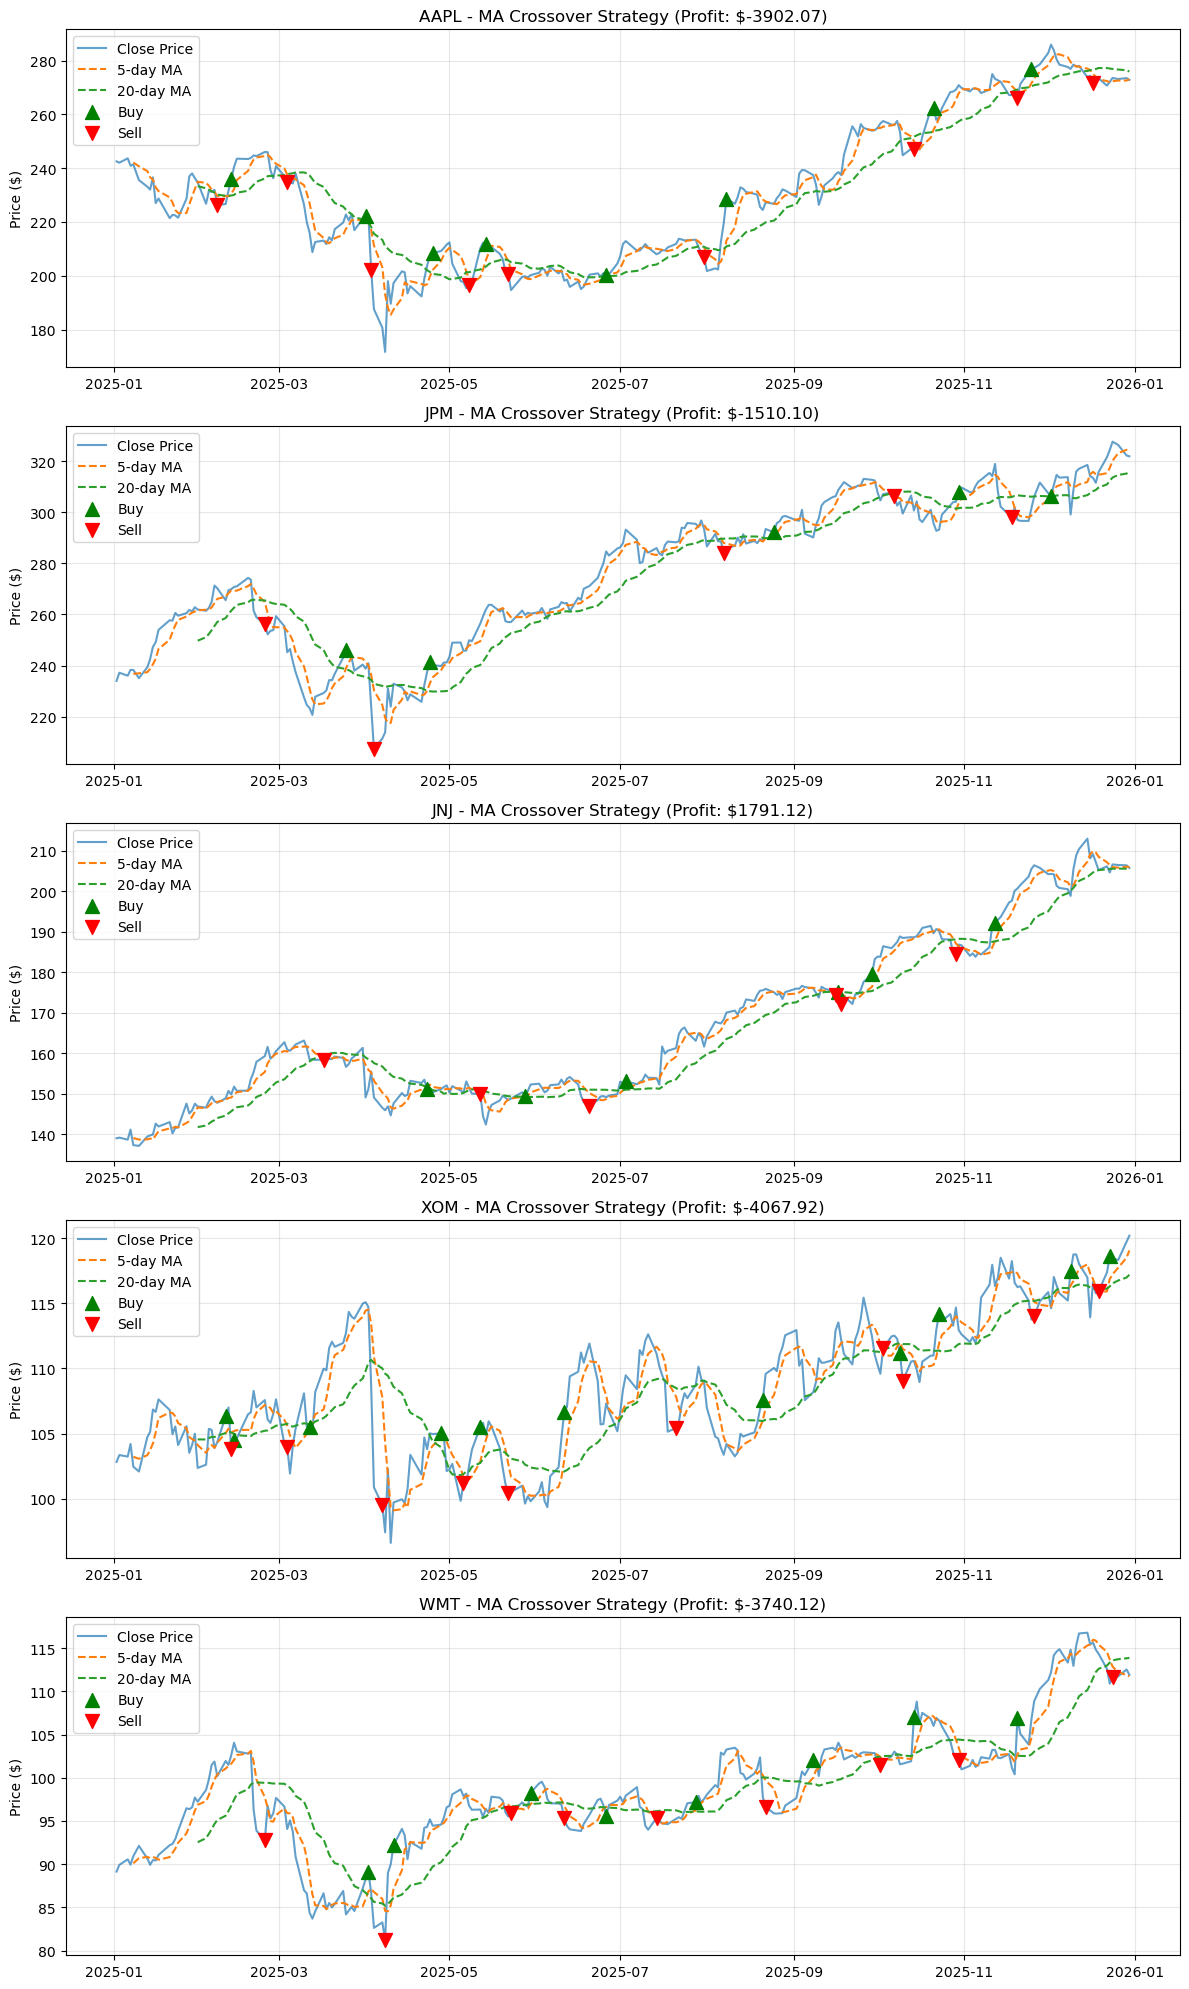

In [3]:
# First trading strategy:
# - A moving average (MA) crossover strategy using a 5-day short-term window and a 20-day long-term window

# 1.1a Calculate moving average (MA)
short_window = 5
long_window = 20

ma_short = data.rolling(window=short_window).mean()
ma_long = data.rolling(window=long_window).mean()

# Generate MA signals: +1 = buy (short MA crosses above long MA), -1 = sell
ma_signal = pd.DataFrame(0.0, index=data.index, columns=stocks)
ma_signal[ma_short > ma_long] = 1.0
ma_signal[ma_short <= ma_long] = -1.0

# Detect trades: a trade occurs when the signal changes
ma_trades = ma_signal.diff().fillna(0)

# Calculate daily returns and strategy returns
daily_returns = data.pct_change().fillna(0)
# Shift signal by 1 to avoid look-ahead bias
ma_strategy_returns = ma_signal.shift(1).fillna(0) * daily_returns

# Calculate cumulative portfolio value for each stock
ma_portfolio = INITIAL_CAPITAL * (1 + ma_strategy_returns).cumprod()
ma_profit = ma_portfolio.iloc[-1] - INITIAL_CAPITAL

print("=== MA Crossover Strategy Profits ===")
for stock in stocks:
    print(f"{stock}: ${ma_profit[stock]:.2f}")

# 1.1b Visualize the data in 5 (sub)plots
fig, axes = plt.subplots(5, 1, figsize=(12, 20))
for i, stock in enumerate(stocks):
    axes[i].plot(data.index, data[stock], label="Close Price", alpha=0.7)
    axes[i].plot(data.index, ma_short[stock], label=f"{short_window}-day MA", linestyle="--")
    axes[i].plot(data.index, ma_long[stock], label=f"{long_window}-day MA", linestyle="--")

    # Mark buy and sell signals
    buy_signals = ma_trades[stock] == 2.0   # Signal changed from -1 to +1
    sell_signals = ma_trades[stock] == -2.0  # Signal changed from +1 to -1
    axes[i].scatter(data.index[buy_signals], data[stock][buy_signals],
                    marker="^", color="green", s=100, label="Buy", zorder=5)
    axes[i].scatter(data.index[sell_signals], data[stock][sell_signals],
                    marker="v", color="red", s=100, label="Sell", zorder=5)

    axes[i].set_title(f"{stock} - MA Crossover Strategy (Profit: ${ma_profit[stock]:.2f})")
    axes[i].set_ylabel("Price ($)")
    axes[i].legend(loc="upper left")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== RSI Strategy Profits ===
AAPL: $2635.63
JPM: $-3103.38
JNJ: $-1730.79
XOM: $3585.81
WMT: $509.37


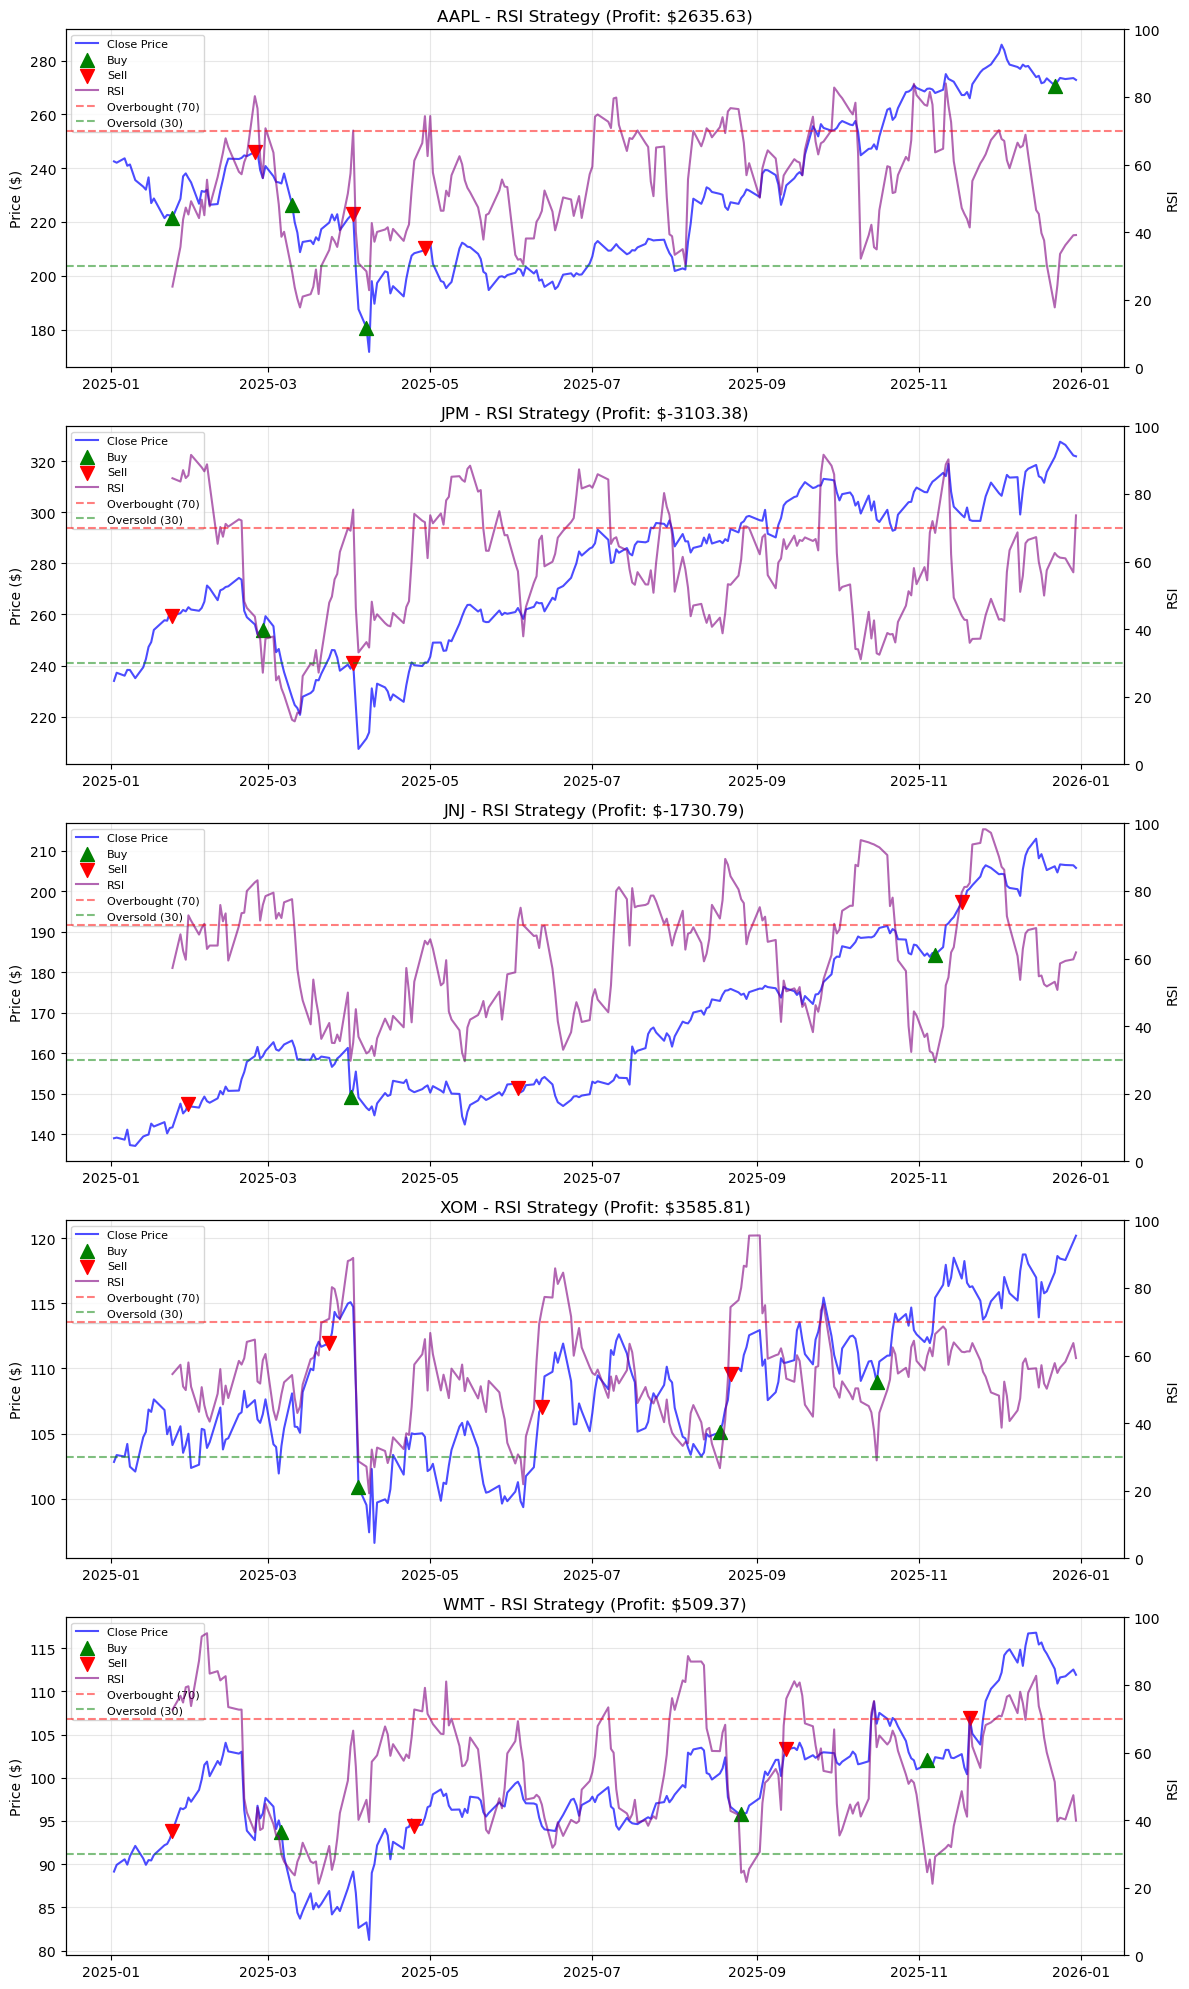

In [4]:
# Second trading strategy:
# - A relative strength index (RSI) strategy with overbought and oversold thresholds set at 70 and 30

# 1.2a Calculate relative strength index (RSI)
rsi_period = 14
delta = data.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=rsi_period).mean()
avg_loss = loss.rolling(window=rsi_period).mean()

rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

# Generate RSI signals: buy when RSI < 30 (oversold), sell when RSI > 70 (overbought)
rsi_signal = pd.DataFrame(0.0, index=data.index, columns=stocks)
for stock in stocks:
    position = 0
    positions = []
    for j in range(len(data)):
        rsi_val = rsi[stock].iloc[j]
        if pd.isna(rsi_val):
            positions.append(0)
            continue
        if rsi_val < 30:    # Oversold -> buy
            position = 1
        elif rsi_val > 70:  # Overbought -> sell
            position = -1
        positions.append(position)
    rsi_signal[stock] = positions

# Detect trades for visualization
rsi_trades = rsi_signal.diff().fillna(0)

# Calculate strategy returns
rsi_strategy_returns = rsi_signal.shift(1).fillna(0) * daily_returns
rsi_portfolio = INITIAL_CAPITAL * (1 + rsi_strategy_returns).cumprod()
rsi_profit = rsi_portfolio.iloc[-1] - INITIAL_CAPITAL

print("=== RSI Strategy Profits ===")
for stock in stocks:
    print(f"{stock}: ${rsi_profit[stock]:.2f}")

# 1.2b Visualize the data in 5 (sub)plots
fig, axes = plt.subplots(5, 1, figsize=(12, 20))
for i, stock in enumerate(stocks):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(data.index, data[stock], label="Close Price", color="blue", alpha=0.7)
    ax2.plot(data.index, rsi[stock], label="RSI", color="purple", alpha=0.6)
    ax2.axhline(y=70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
    ax2.axhline(y=30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")

    # Mark buy and sell signals
    buy_signals = rsi_trades[stock] > 0
    sell_signals = rsi_trades[stock] < 0
    ax1.scatter(data.index[buy_signals], data[stock][buy_signals],
               marker="^", color="green", s=100, label="Buy", zorder=5)
    ax1.scatter(data.index[sell_signals], data[stock][sell_signals],
               marker="v", color="red", s=100, label="Sell", zorder=5)

    ax1.set_title(f"{stock} - RSI Strategy (Profit: ${rsi_profit[stock]:.2f})")
    ax1.set_ylabel("Price ($)")
    ax2.set_ylabel("RSI")
    ax2.set_ylim(0, 100)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Profit Comparison ===
      MA Crossover Profit ($)  RSI Profit ($) Better Strategy
AAPL             -3902.065074     2635.629070             RSI
JPM              -1510.100324    -3103.379995              MA
JNJ               1791.121941    -1730.786280              MA
XOM              -4067.924695     3585.813121             RSI
WMT              -3740.121517      509.371613             RSI


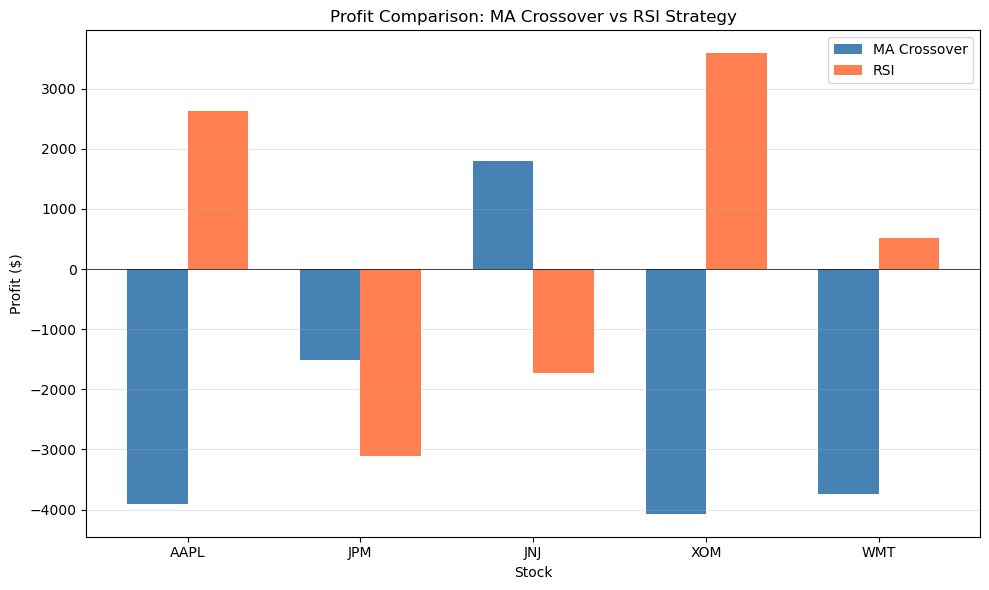

In [5]:
# 1.3 Compare profits across companies and between strategies
comparison = pd.DataFrame({
    "MA Crossover Profit ($)": ma_profit,
    "RSI Profit ($)": rsi_profit
})
comparison["Better Strategy"] = comparison.apply(
    lambda row: "MA" if row["MA Crossover Profit ($)"] > row["RSI Profit ($)"] else "RSI", axis=1
)
print("=== Profit Comparison ===")
print(comparison.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(stocks))
width = 0.35
ax.bar(x - width/2, ma_profit.values, width, label="MA Crossover", color="steelblue")
ax.bar(x + width/2, rsi_profit.values, width, label="RSI", color="coral")
ax.set_xlabel("Stock")
ax.set_ylabel("Profit ($)")
ax.set_title("Profit Comparison: MA Crossover vs RSI Strategy")
ax.set_xticks(x)
ax.set_xticklabels(stocks)
ax.legend()
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ============================== Findings ==============================
#
# 1) Comparison across companies:
#    - MA Crossover: Only JNJ was profitable (+$1,791). The other four stocks
#      all lost money: AAPL (-$3,902), XOM (-$4,068), WMT (-$3,740),
#      JPM (-$1,510). Average profit: -$2,286.
#    - RSI: Three stocks were profitable: XOM (+$3,586), AAPL (+$2,636),
#      WMT (+$509). JPM (-$3,103) and JNJ (-$1,731) lost money.
#      Average profit: +$379.
#
# 2) Comparison between strategies:
#    - RSI outperformed MA on 3 out of 5 stocks (AAPL, XOM, WMT).
#    - MA outperformed RSI on 2 stocks (JPM, JNJ).
#    - Overall, RSI (avg +$379) significantly beat MA (avg -$2,286).
#
# 3) Interpretation:
#    - The 5/20-day MA crossover generated frequent whipsaw (false) signals
#      in 2025 volatile, choppy market, leading to repeated buy-high /
#      sell-low trades and large cumulative losses.
#    - RSI performed better because many stocks exhibited mean-reverting
#      behavior in 2025. Buying at oversold levels (RSI < 30) and selling
#      at overbought levels (RSI > 70) captured profitable price rebounds.
#    - Performance is stock-dependent: JNJ (Healthcare) had a clearer trend
#      that favored MA, while AAPL (Tech) and XOM (Energy) oscillated
#      more frequently, favoring the RSI mean-reversion approach.

### Q1 Findings: Comparison of MA Crossover vs RSI Strategy

**1) Comparison across companies:**
- **MA Crossover:** Only JNJ was profitable (+\$1,791). The other four stocks all lost money: AAPL (-\$3,902), XOM (-\$4,068), WMT (-\$3,740), JPM (-\$1,510). **Average profit: -\$2,286.**
- **RSI:** Three stocks were profitable: XOM (+\$3,586), AAPL (+\$2,636), WMT (+\$509). JPM (-\$3,103) and JNJ (-\$1,731) lost money. **Average profit: +\$379.**

**2) Comparison between strategies:**
- RSI outperformed MA on 3 out of 5 stocks (AAPL, XOM, WMT).
- MA outperformed RSI on 2 stocks (JPM, JNJ).
- Overall, RSI (avg +\$379) significantly beat MA (avg -\$2,286).

**3) Interpretation:**
- The 5/20-day MA crossover generated frequent **whipsaw (false) signals** in 2025's volatile, choppy market, leading to repeated buy-high / sell-low trades and large cumulative losses.
- RSI performed better because many stocks exhibited **mean-reverting behavior** in 2025. Buying at oversold levels (RSI < 30) and selling at overbought levels (RSI > 70) captured profitable price rebounds.
- Performance is **stock-dependent**: JNJ (Healthcare) had a clearer trend that favored MA, while AAPL (Tech) and XOM (Energy) oscillated more frequently, favoring the RSI mean-reversion approach.

# Q2: Sensitivity Analysis of MA Window Sizes

In [6]:
# 2.1 Vary the short-term window between 2-20 days and the long-term window between 5-100 days.

def ma_strategy_profit(prices, short_w, long_w, capital=INITIAL_CAPITAL):
    """Calculate profit for MA crossover strategy with given window sizes."""
    ma_s = prices.rolling(window=short_w).mean()
    ma_l = prices.rolling(window=long_w).mean()
    signal = pd.Series(0.0, index=prices.index)
    signal[ma_s > ma_l] = 1.0
    signal[ma_s <= ma_l] = -1.0
    ret = prices.pct_change().fillna(0)
    strategy_ret = signal.shift(1).fillna(0) * ret
    portfolio_value = capital * (1 + strategy_ret).cumprod()
    return portfolio_value.iloc[-1] - capital

short_range = range(2, 21)   # 2 to 20 days
long_range = range(5, 101)   # 5 to 100 days

# Calculate profit for each combination, averaged across all 5 stocks
profit_matrix = pd.DataFrame(index=list(short_range), columns=list(long_range), dtype=float)

for s in short_range:
    for l in long_range:
        if s >= l:  # Short window must be less than long window
            profit_matrix.loc[s, l] = np.nan
            continue
        total_profit = 0
        for stock in stocks:
            total_profit += ma_strategy_profit(data[stock], s, l)
        profit_matrix.loc[s, l] = total_profit / len(stocks)

print(f"Profit matrix shape: {profit_matrix.shape}")
print(f"Best combination: short={profit_matrix.stack().idxmax()[0]}, long={profit_matrix.stack().idxmax()[1]}")
print(f"Best avg profit: ${profit_matrix.stack().max():.2f}")

Profit matrix shape: (19, 96)
Best combination: short=17, long=92
Best avg profit: $1974.08


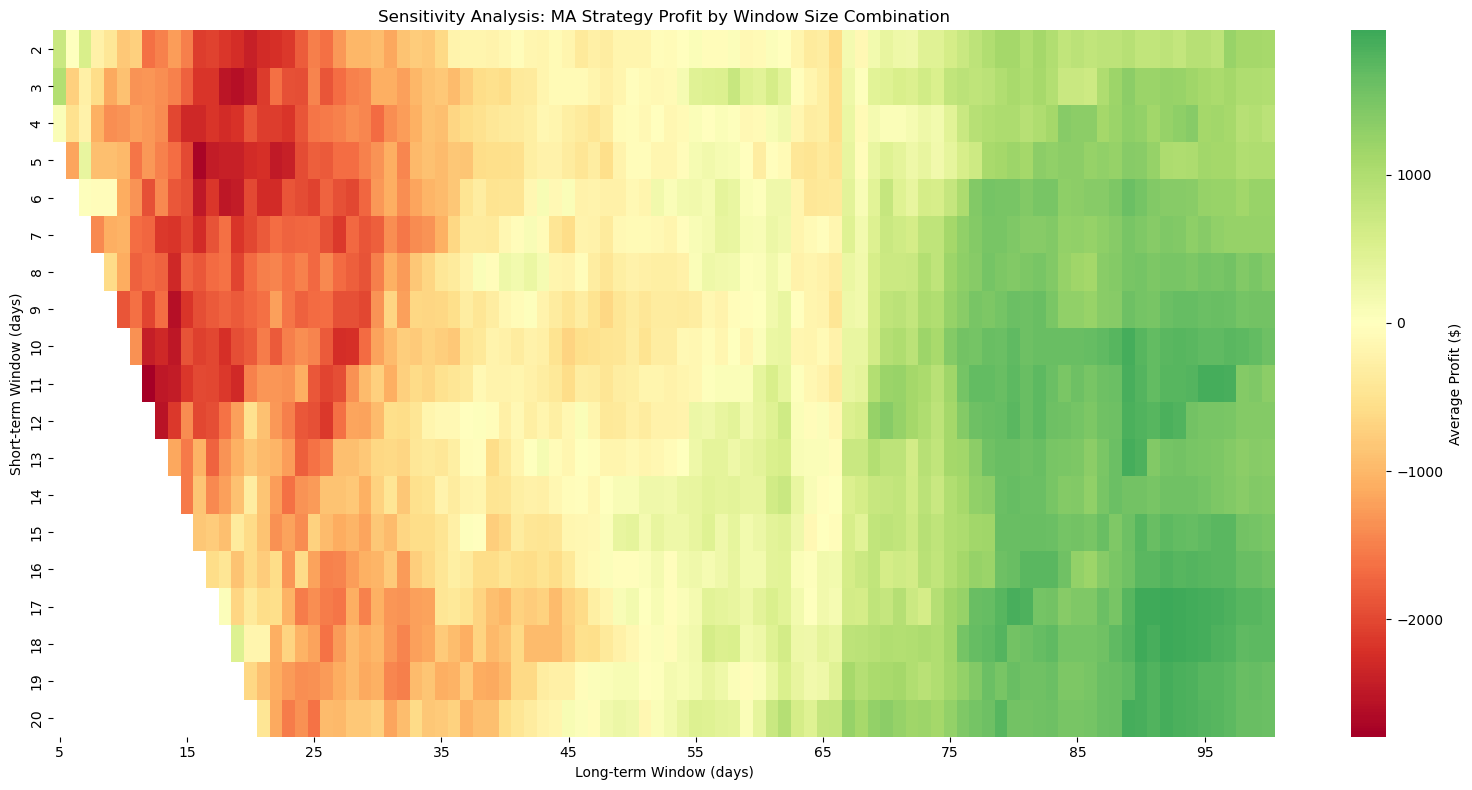

In [7]:
# 2.2 Visualize the resulting profits for different combinations using a heatmap in Matplotlib.
fig, ax = plt.subplots(figsize=(16, 8))

heatmap_data = profit_matrix.astype(float)

sns.heatmap(heatmap_data, ax=ax, cmap="RdYlGn", center=0,
            xticklabels=10, yticklabels=1,
            cbar_kws={"label": "Average Profit ($)"})

ax.set_xlabel("Long-term Window (days)")
ax.set_ylabel("Short-term Window (days)")
ax.set_title("Sensitivity Analysis: MA Strategy Profit by Window Size Combination")
plt.tight_layout()
plt.show()

# ============================== Findings ==============================
#
# 1) The optimal window combination is short=17, long=92, yielding an average
#    profit of $1,974 across the 5 stocks. This is a dramatic improvement over
#    the default 5/20 windows which averaged -$2,286 (a swing of over $4,200).
#
# 2) The heatmap reveals that larger window separations (e.g., short ~15-20,
#    long ~70-100) tend to produce higher profits. These wider gaps reduce
#    the frequency of crossover signals, filtering out short-term noise and
#    only capturing more sustained trend reversals.
#
# 3) Small short-term windows (2-5) paired with small long-term windows
#    (5-20) consistently produce the worst results (deep red in the heatmap),
#    confirming that the default 5/20 setup was overly sensitive to noise.
#
# 4) This demonstrates that window size selection is critical to MA strategy
#    performance. The same strategy logic can swing from -$2,286 to +$1,974
#    simply by tuning the parameters, highlighting the importance of
#    backtesting and parameter optimization before deploying a strategy.

### Q2 Findings: Sensitivity Analysis of MA Window Sizes

**1)** The optimal window combination is **short=17, long=92**, yielding an average profit of **+\$1,974** across the 5 stocks. This is a dramatic improvement over the default 5/20 windows which averaged -\$2,286 (a swing of over \$4,200).

**2)** The heatmap reveals that **larger window separations** (e.g., short ~15-20, long ~70-100) tend to produce higher profits. These wider gaps reduce the frequency of crossover signals, filtering out short-term noise and only capturing more sustained trend reversals.

**3)** Small short-term windows (2-5) paired with small long-term windows (5-20) consistently produce the **worst results** (deep red in the heatmap), confirming that the default 5/20 setup was overly sensitive to noise.

**4)** This demonstrates that **window size selection is critical** to MA strategy performance. The same strategy logic can swing from -\$2,286 to +\$1,974 simply by tuning the parameters, highlighting the importance of backtesting and parameter optimization before deploying a strategy.

# 3: Strategy Integration: Combining MA and RSI

=== Hybrid Strategy Profits ===
AAPL: $-1739.27
JPM: $-1204.15
JNJ: $1443.35
XOM: $-2793.98
WMT: $-4165.66


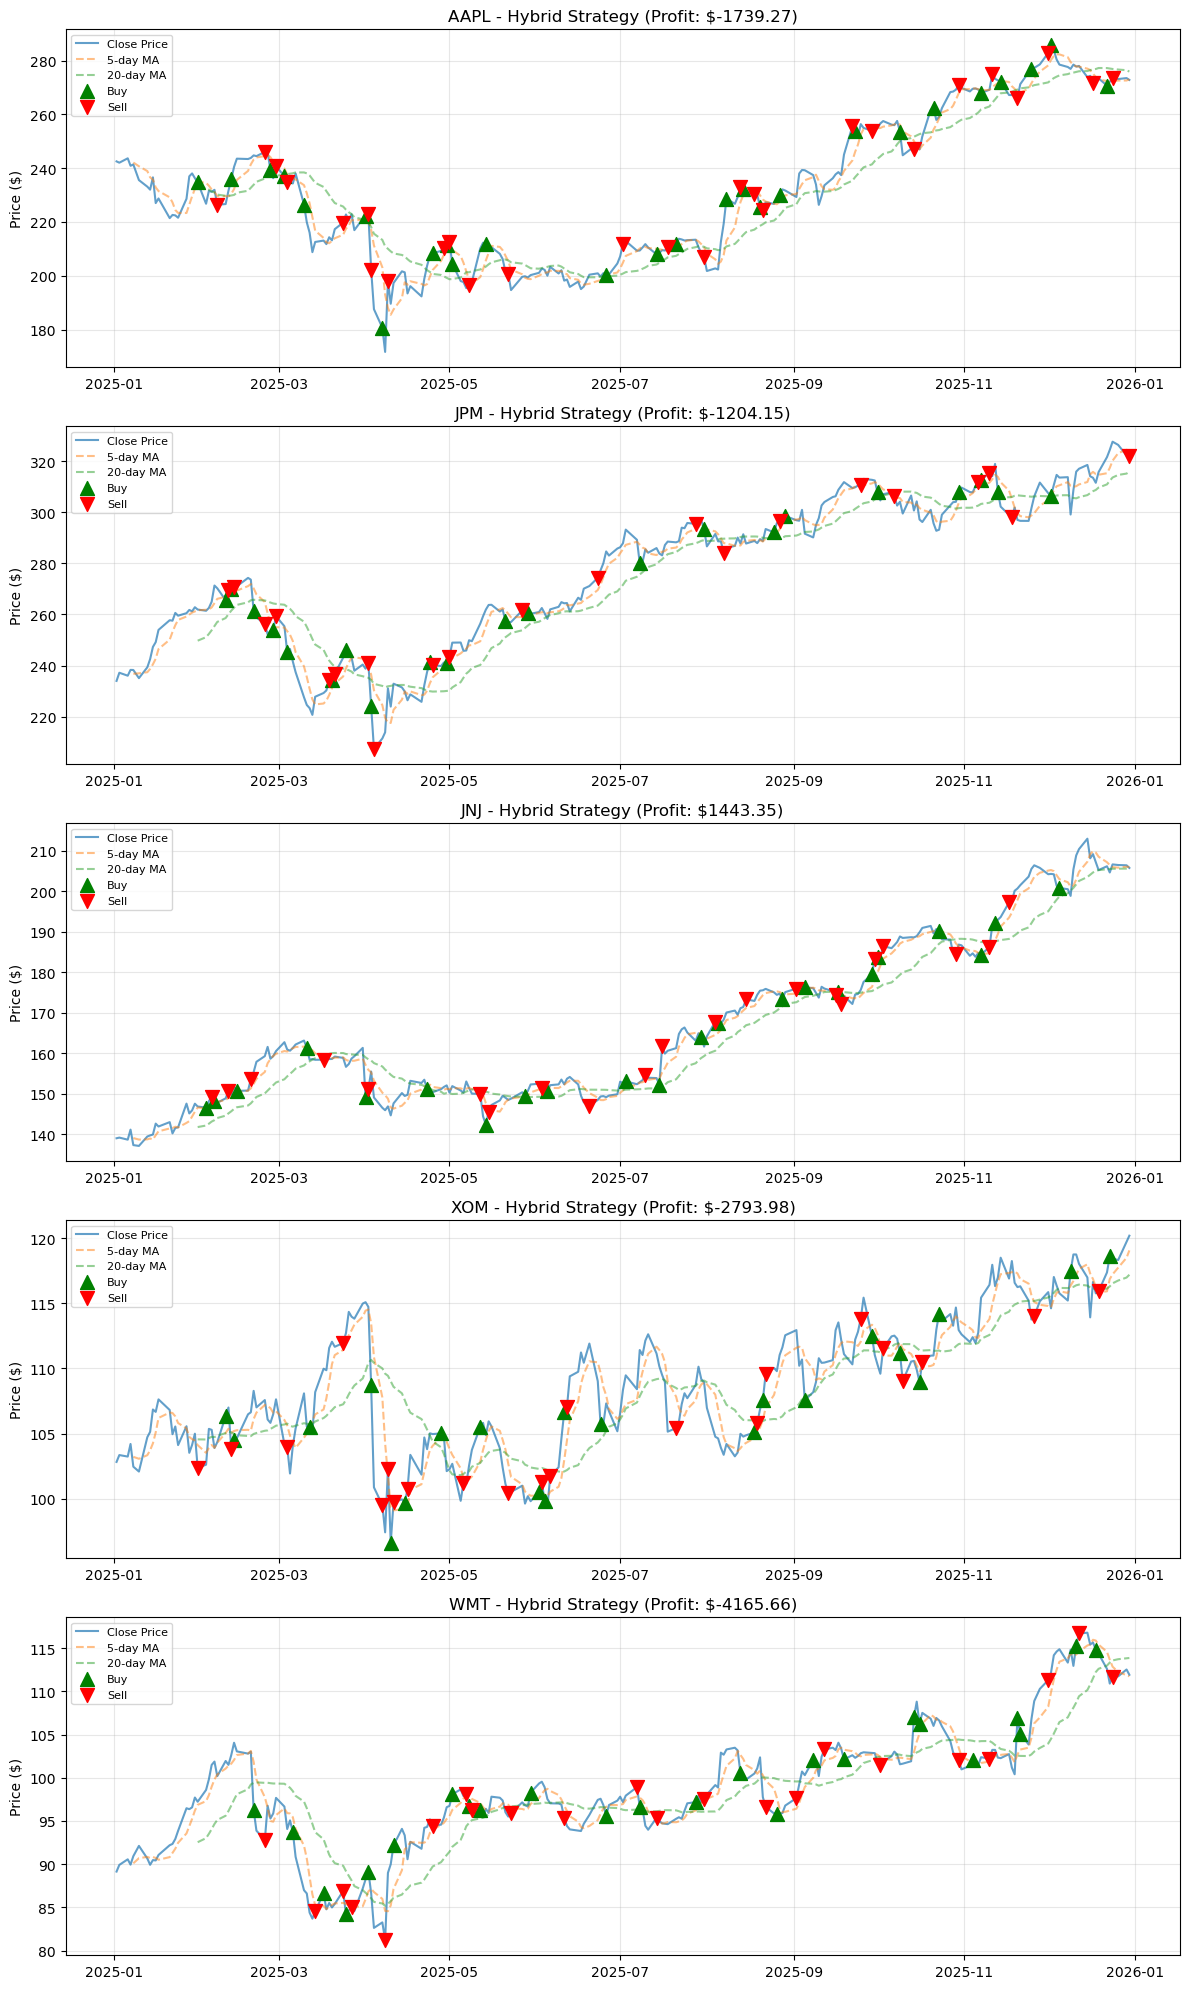

In [8]:
# 3.1 Integrate both strategies into a single trading logic
# Hybrid rule:
#   Buy  (+1) when MA signal is bullish (short MA > long MA) AND RSI < 70 (not overbought)
#   Sell (-1) when MA signal is bearish (short MA < long MA) AND RSI > 30 (not oversold)
#   Hold (0) otherwise (conflicting signals)

hybrid_signal = pd.DataFrame(0.0, index=data.index, columns=stocks)

for stock in stocks:
    positions = []
    for j in range(len(data)):
        ma_bull = ma_signal[stock].iloc[j] == 1.0
        ma_bear = ma_signal[stock].iloc[j] == -1.0
        rsi_val = rsi[stock].iloc[j]

        if pd.isna(rsi_val):
            positions.append(0.0)
        elif ma_bull and rsi_val < 70:
            # MA says uptrend + RSI confirms not overbought -> buy
            positions.append(1.0)
        elif ma_bear and rsi_val > 30:
            # MA says downtrend + RSI confirms not oversold -> sell
            positions.append(-1.0)
        else:
            # Conflicting signals -> hold (no position)
            positions.append(0.0)
    hybrid_signal[stock] = positions

# Calculate hybrid strategy returns
hybrid_strategy_returns = hybrid_signal.shift(1).fillna(0) * daily_returns
hybrid_portfolio = INITIAL_CAPITAL * (1 + hybrid_strategy_returns).cumprod()
hybrid_profit = hybrid_portfolio.iloc[-1] - INITIAL_CAPITAL

print("=== Hybrid Strategy Profits ===")
for stock in stocks:
    print(f"{stock}: ${hybrid_profit[stock]:.2f}")

# Visualize hybrid strategy
fig, axes = plt.subplots(5, 1, figsize=(12, 20))
hybrid_trades = hybrid_signal.diff().fillna(0)

for i, stock in enumerate(stocks):
    axes[i].plot(data.index, data[stock], label="Close Price", alpha=0.7)
    axes[i].plot(data.index, ma_short[stock], label=f"{short_window}-day MA", linestyle="--", alpha=0.5)
    axes[i].plot(data.index, ma_long[stock], label=f"{long_window}-day MA", linestyle="--", alpha=0.5)

    buy_signals = hybrid_trades[stock] > 0
    sell_signals = hybrid_trades[stock] < 0
    axes[i].scatter(data.index[buy_signals], data[stock][buy_signals],
                    marker="^", color="green", s=100, label="Buy", zorder=5)
    axes[i].scatter(data.index[sell_signals], data[stock][sell_signals],
                    marker="v", color="red", s=100, label="Sell", zorder=5)

    axes[i].set_title(f"{stock} - Hybrid Strategy (Profit: ${hybrid_profit[stock]:.2f})")
    axes[i].set_ylabel("Price ($)")
    axes[i].legend(loc="upper left", fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Final Strategy Comparison ===
      MA Crossover ($)      RSI ($)   Hybrid ($)     Best Strategy
AAPL      -3902.065074  2635.629070 -1739.266043           RSI ($)
JPM       -1510.100324 -3103.379995 -1204.146436        Hybrid ($)
JNJ        1791.121941 -1730.786280  1443.347502  MA Crossover ($)
XOM       -4067.924695  3585.813121 -2793.982167           RSI ($)
WMT       -3740.121517   509.371613 -4165.660841           RSI ($)

Average MA Profit:     $-2285.82
Average RSI Profit:    $379.33
Average Hybrid Profit: $-1691.94


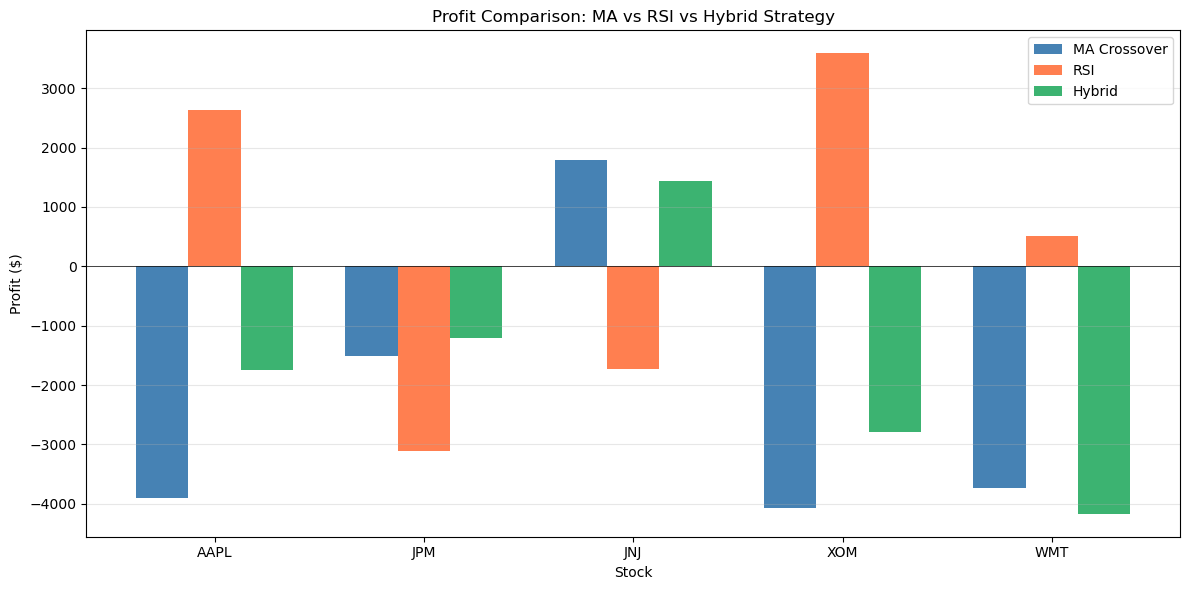

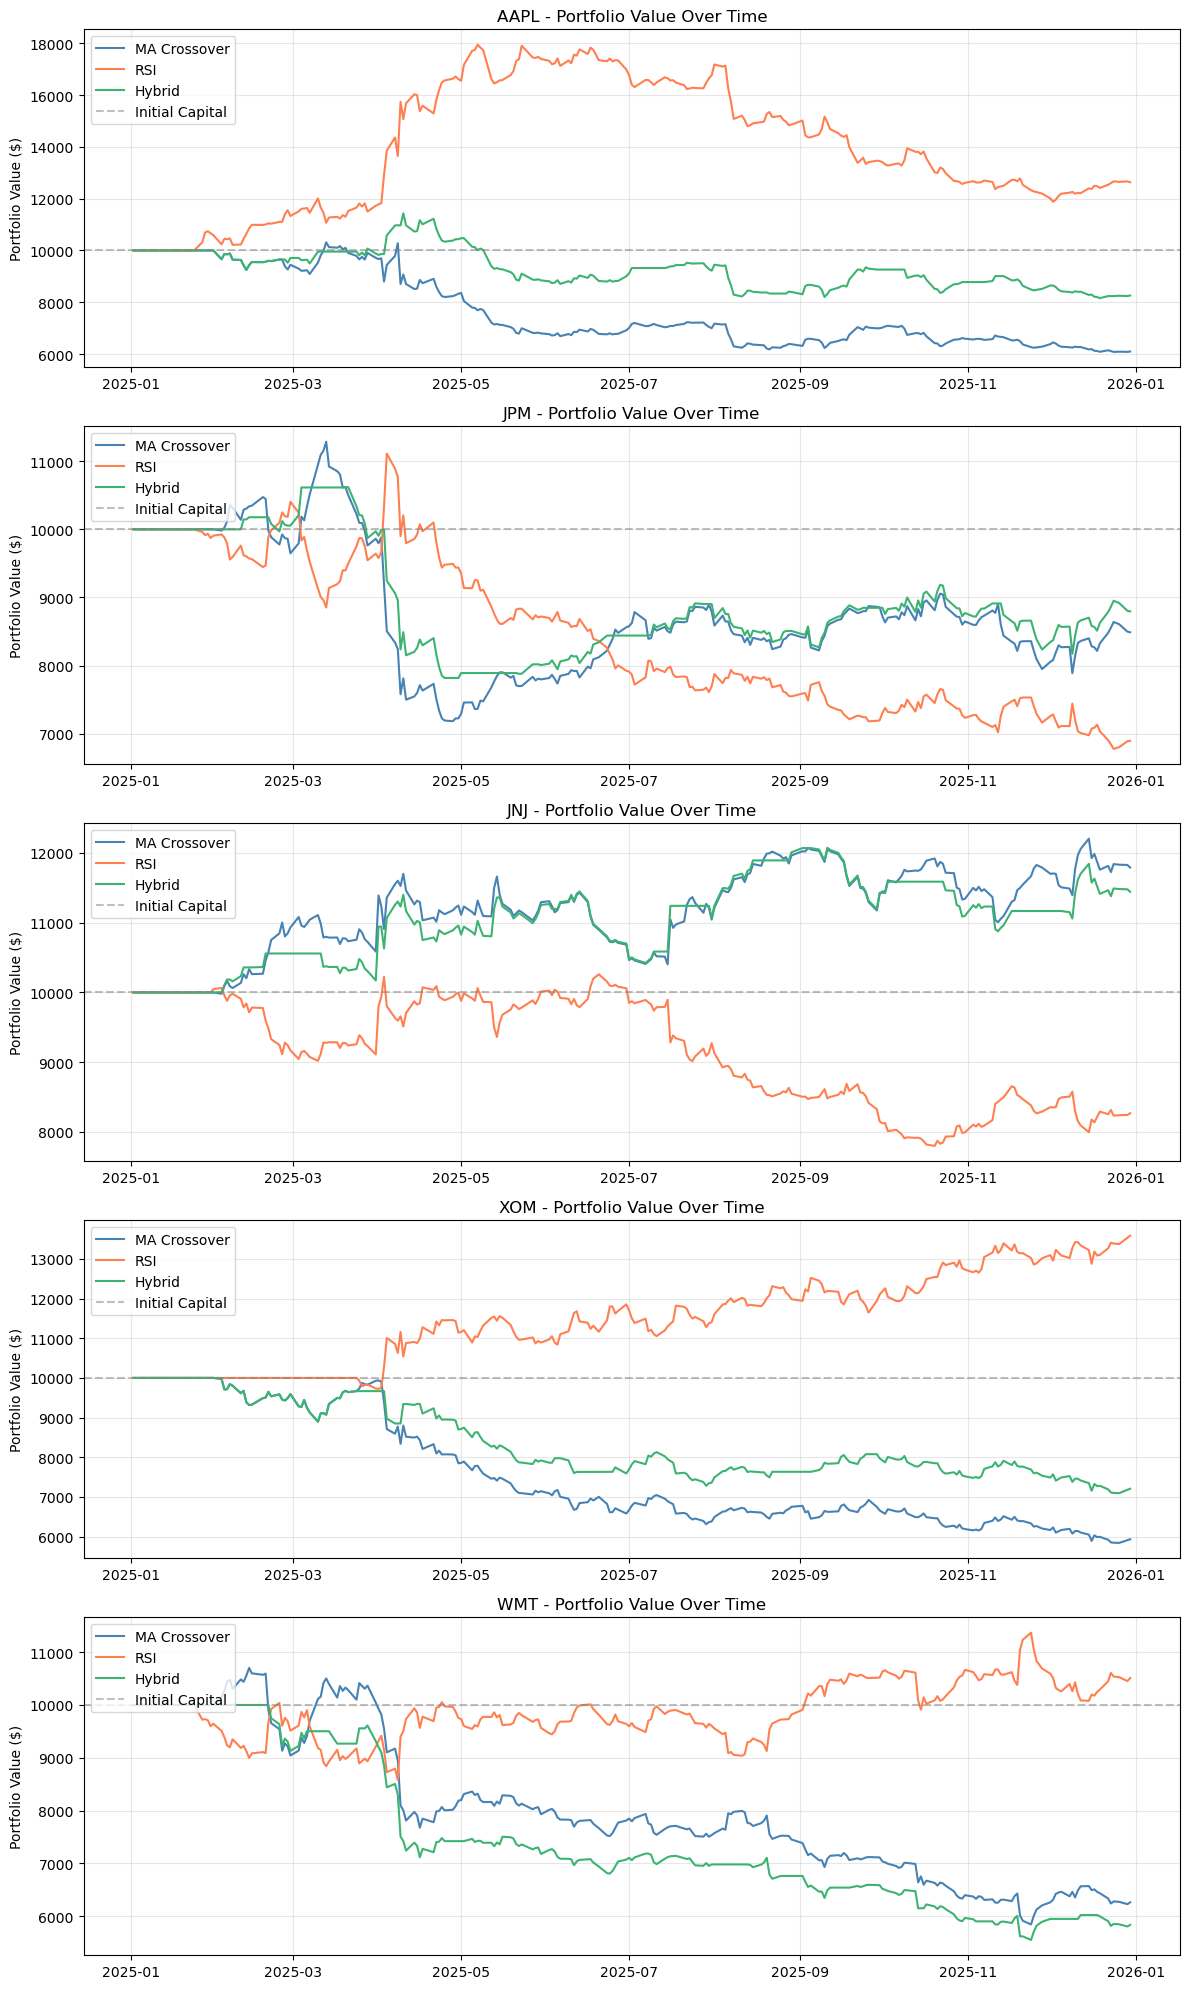

In [9]:
# 3.2 Evaluate whether this hybrid approach enhances investment performance
final_comparison = pd.DataFrame({
    "MA Crossover ($)": ma_profit,
    "RSI ($)": rsi_profit,
    "Hybrid ($)": hybrid_profit
})

final_comparison["Best Strategy"] = final_comparison[
    ["MA Crossover ($)", "RSI ($)", "Hybrid ($)"]
].idxmax(axis=1)

print("=== Final Strategy Comparison ===")
print(final_comparison.to_string())
print(f"\nAverage MA Profit:     ${ma_profit.mean():.2f}")
print(f"Average RSI Profit:    ${rsi_profit.mean():.2f}")
print(f"Average Hybrid Profit: ${hybrid_profit.mean():.2f}")

# Bar chart: all 3 strategies side by side
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(stocks))
width = 0.25
ax.bar(x - width, ma_profit.values, width, label="MA Crossover", color="steelblue")
ax.bar(x, rsi_profit.values, width, label="RSI", color="coral")
ax.bar(x + width, hybrid_profit.values, width, label="Hybrid", color="mediumseagreen")
ax.set_xlabel("Stock")
ax.set_ylabel("Profit ($)")
ax.set_title("Profit Comparison: MA vs RSI vs Hybrid Strategy")
ax.set_xticks(x)
ax.set_xticklabels(stocks)
ax.legend()
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Cumulative portfolio value over time
fig, axes = plt.subplots(5, 1, figsize=(12, 20))
for i, stock in enumerate(stocks):
    axes[i].plot(data.index, ma_portfolio[stock], label="MA Crossover", color="steelblue")
    axes[i].plot(data.index, rsi_portfolio[stock], label="RSI", color="coral")
    axes[i].plot(data.index, hybrid_portfolio[stock], label="Hybrid", color="mediumseagreen")
    axes[i].axhline(y=INITIAL_CAPITAL, color="gray", linestyle="--", alpha=0.5, label="Initial Capital")
    axes[i].set_title(f"{stock} - Portfolio Value Over Time")
    axes[i].set_ylabel("Portfolio Value ($)")
    axes[i].legend(loc="upper left")
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================== Findings ==============================
#
# 1) Performance ranking (by average profit across 5 stocks):
#    - RSI standalone:   +$379   (best)
#    - Hybrid (MA+RSI):  -$1,692 (middle)
#    - MA standalone:    -$2,286 (worst)
#
# 2) Per-stock breakdown:
#    - AAPL: RSI (+$2,636) >> Hybrid (-$1,739) > MA (-$3,902)
#    - JPM:  Hybrid (-$1,204) > MA (-$1,510) > RSI (-$3,103)
#    - JNJ:  MA (+$1,791) > Hybrid (+$1,443) > RSI (-$1,731)
#    - XOM:  RSI (+$3,586) >> Hybrid (-$2,794) > MA (-$4,068)
#    - WMT:  RSI (+$509) >> MA (-$3,740) > Hybrid (-$4,166)
#
# 3) Does the hybrid enhance performance?
#    - vs. MA alone: YES. The hybrid improved average profit from -$2,286
#      to -$1,692, a gain of ~$594. By requiring RSI confirmation before
#      acting on MA crossovers, the hybrid filtered out some false signals.
#    - vs. RSI alone: NO. The hybrid (avg -$1,692) underperformed RSI
#      (avg +$379) by ~$2,071. Adding the MA trend condition forced the
#      hybrid to exit or avoid positions that RSI alone would have held
#      profitably during mean-reversion moves.
#
# 4) Conclusion:
#    - In 2025 market conditions, the RSI mean-reversion strategy was the
#      clear winner. The hybrid offered partial improvement over MA by reducing
#      whipsaw losses, but it also diluted RSI profitable signals.
#    - The benefit of combining strategies is market-regime dependent. In a
#      stronger trending market, the hybrid could outperform both standalone
#      strategies by using RSI to confirm trend strength and avoid entering
#      during overbought/oversold extremes. In the choppy 2025 market,
#      however, the simpler RSI approach was more effective.

### Q3 Findings: Does the Hybrid Strategy Enhance Performance?

**1) Performance ranking** (by average profit across 5 stocks):

| Strategy | Average Profit |
|----------|---------------|
| RSI standalone | +\$379 (best) |
| Hybrid (MA+RSI) | -\$1,692 (middle) |
| MA standalone | -\$2,286 (worst) |

**2) Per-stock breakdown:**
- AAPL: RSI (+\$2,636) >> Hybrid (-\$1,739) > MA (-\$3,902)
- JPM: Hybrid (-\$1,204) > MA (-\$1,510) > RSI (-\$3,103)
- JNJ: MA (+\$1,791) > Hybrid (+\$1,443) > RSI (-\$1,731)
- XOM: RSI (+\$3,586) >> Hybrid (-\$2,794) > MA (-\$4,068)
- WMT: RSI (+\$509) >> MA (-\$3,740) > Hybrid (-\$4,166)

**3) Does the hybrid enhance performance?**
- **vs. MA alone: YES.** The hybrid improved average profit from -\$2,286 to -\$1,692, a gain of ~\$594. By requiring RSI confirmation before acting on MA crossovers, the hybrid filtered out some false signals.
- **vs. RSI alone: NO.** The hybrid (avg -\$1,692) underperformed RSI (avg +\$379) by ~\$2,071. Adding the MA trend condition forced the hybrid to exit or avoid positions that RSI alone would have held profitably during mean-reversion moves.

**4) Conclusion:**
- In 2025's market conditions, the **RSI mean-reversion strategy was the clear winner**. The hybrid offered partial improvement over MA by reducing whipsaw losses, but it also diluted RSI's profitable signals.
- The benefit of combining strategies is **market-regime dependent**. In a stronger trending market, the hybrid could outperform both standalone strategies by using RSI to confirm trend strength and avoid entering during overbought/oversold extremes. In the choppy 2025 market, however, the simpler RSI approach was more effective.